In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#load dataset
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,
                   columns=housing.feature_names)
data["Price"]=housing.target

In [3]:
#select one feature
X=data[['AveRooms']].values
Y=data['Price'].values

In [4]:
#split data
X_train,X_test,Y_train,Y_test=train_test_split(
        X,Y,
        test_size=0.2,
        random_state=42
)

In [5]:
#feature scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
w=0
b=0

learning_rate = 0.01
epochs = 1000

n=len(X_train_scaled)
cost_history = []

for i in range(epochs):
    Y_pred = w * X_train_scaled.flatten() + b
    dw =(1/n) * np.sum((Y_pred - Y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(Y_pred - Y_train)
    w = w -learning_rate *dw
    b = b -learning_rate *db
    cost = (1/(2*n)) * np.sum((Y_pred - Y_train) ** 2)
    cost_history.append(cost)
    if i % 100 == 0:   
        print(f"Epoch {i}, Cost = {cost: .4f}") 
y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0, Cost =  2.8149
Epoch 100, Cost =  0.9414
Epoch 200, Cost =  0.6904
Epoch 300, Cost =  0.6568
Epoch 400, Cost =  0.6523
Epoch 500, Cost =  0.6517
Epoch 600, Cost =  0.6516
Epoch 700, Cost =  0.6516
Epoch 800, Cost =  0.6516
Epoch 900, Cost =  0.6516


In [7]:
print("Gradient descent")
print("-------------------")
print("Weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(Y_test, y_pred_gd))
print("R2 score:",r2_score(Y_test, y_pred_gd))

Gradient descent
-------------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 score: 0.013798228607320828


In [8]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta=np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ Y_train
Y_pred_ne=X_test_ne @ theta

In [9]:
print("\nNormal equation")
print("-------------------------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(Y_test,Y_pred_ne))
print("R2 score:",r2_score(Y_test,Y_pred_ne))


Normal equation
-------------------------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 score: 0.013795337532284901


In [10]:
#sort values for smooth regression lines

sort_axis=np.argsort(X_test.flatten())
X_sorted=X_test[sort_axis]
Y_pred_ne_sorted=Y_pred_ne[sort_axis]

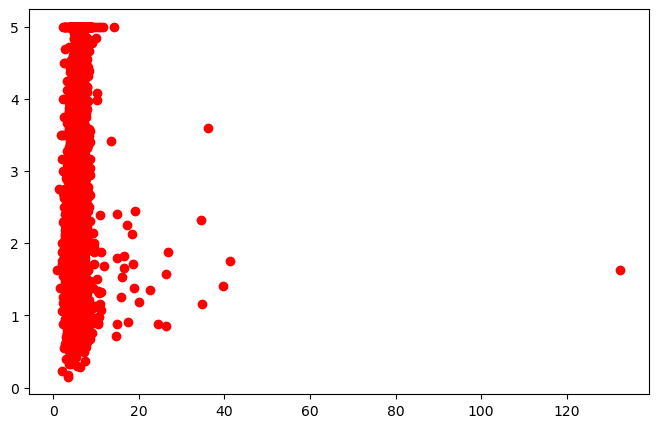

In [11]:
#regression line visualization

#sort x values for a smooth line
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))

#scatter plot
plt.scatter(X_test, Y_test, color='red',label='Actual Data')

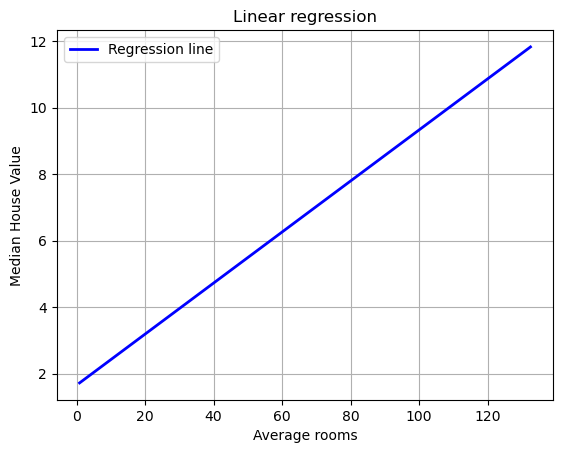

In [12]:
#regression line
plt.plot(
    X_test.flatten()[index],
    Y_pred_ne[index],
    color='blue',
    linewidth=2,
    label='Regression line'
)
plt.title("Linear regression")
plt.xlabel("Average rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

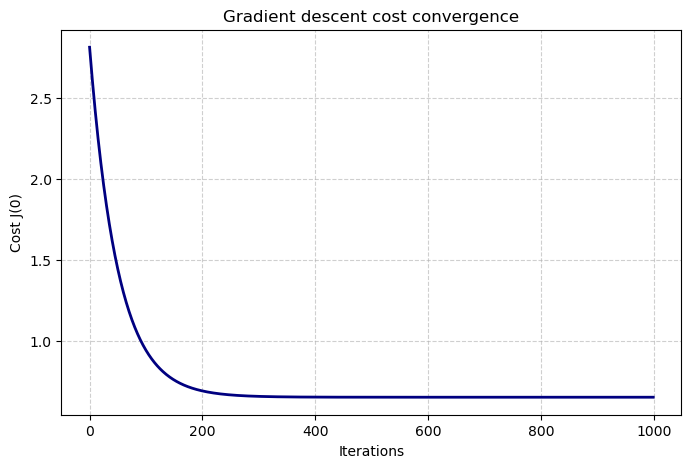

In [13]:
#cost convergence curve

plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title("Gradient descent cost convergence")
plt.xlabel('Iterations')
plt.ylabel('Cost J(0)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show() 